# Diabetes prediction

Pima Indians dataset, 768 patients, 8 measurements each. Screening problem, so
recall and ROC-AUC matter more than plain accuracy.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)

SEED = 42

In [2]:
df = pd.read_csv("../data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# ~35% positive, so accuracy alone is misleading
df["Outcome"].value_counts(normalize=True).round(3)

Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

Glucose, BloodPressure, SkinThickness, Insulin and BMI have zeros that aren't
physically possible. Treat them as missing and impute later.

In [4]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols] = df[cols].replace(0, np.nan)
df[cols].isna().sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [5]:
X = df.drop(columns="Outcome")
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

In [6]:
# impute + scale inside the pipeline so they're fit on train folds only
def pipe_for(model):
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("model", model),
    ])

models = {
    "logreg": LogisticRegression(max_iter=1000),
    "svm": SVC(kernel="linear", probability=True, random_state=SEED),
    "rf": RandomForestClassifier(n_estimators=300, random_state=SEED),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for name, m in models.items():
    auc = cross_val_score(pipe_for(m), X_train, y_train, cv=cv, scoring="roc_auc")
    print(f"{name:7s} AUC {auc.mean():.3f} +/- {auc.std():.3f}")

logreg  AUC 0.843 +/- 0.019
svm     AUC 0.845 +/- 0.016


rf      AUC 0.821 +/- 0.020


In [7]:
# logreg is the most stable and easiest to read, so go with it
clf = pipe_for(LogisticRegression(max_iter=1000)).fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(f"accuracy  {accuracy_score(y_test, y_pred):.3f}")
print(f"precision {precision_score(y_test, y_pred):.3f}")
print(f"recall    {recall_score(y_test, y_pred):.3f}")
print(f"f1        {f1_score(y_test, y_pred):.3f}")
print(f"roc-auc   {roc_auc_score(y_test, y_proba):.3f}")

accuracy  0.708
precision 0.600
recall    0.500
f1        0.545
roc-auc   0.813


In [8]:
print(classification_report(y_test, y_pred, target_names=["no", "diabetic"]))

              precision    recall  f1-score   support

          no       0.75      0.82      0.78       100
    diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



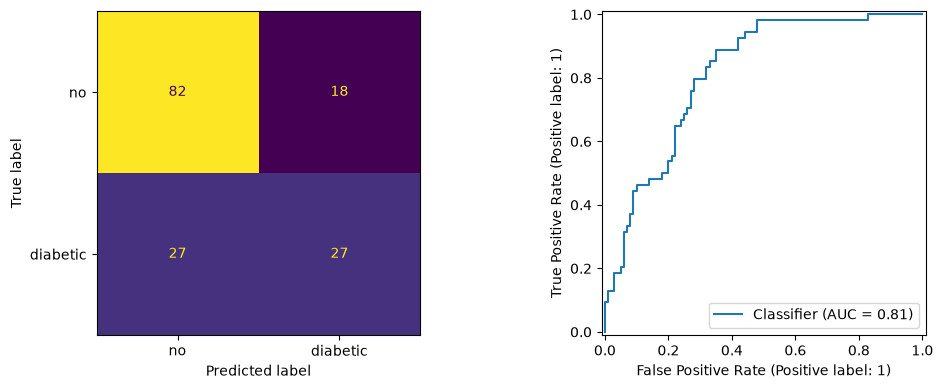

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=["no", "diabetic"]).plot(ax=ax[0], colorbar=False)
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax[1])
plt.tight_layout()
plt.show()

Default threshold misses too many diabetics for a screening tool. Dropping it to
0.35 trades some precision for better recall.

In [10]:
for t in [0.5, 0.35]:
    pred = (y_proba >= t).astype(int)
    print(f"threshold {t}: recall {recall_score(y_test, pred):.3f}, "
          f"precision {precision_score(y_test, pred):.3f}")

threshold 0.5: recall 0.500, precision 0.600
threshold 0.35: recall 0.685, precision 0.587


In [11]:
patient = pd.DataFrame([{
    "Pregnancies": 5, "Glucose": 166, "BloodPressure": 72, "SkinThickness": 19,
    "Insulin": 175, "BMI": 25.8, "DiabetesPedigreeFunction": 0.587, "Age": 51,
}])
print(f"P(diabetes) = {clf.predict_proba(patient)[0, 1]:.2%}")

P(diabetes) = 63.98%
